In [ ]:
from google.colab import auth
auth.authenticate_user()

In [ ]:
!gsutil cp gs://data-science-challenge-data/TestData.csv .

Copying gs://data-science-challenge-data/TestData.csv...
/ [1 files][  2.8 MiB/  2.8 MiB]                                                
Operation completed over 1 objects/2.8 MiB.                                      


In [ ]:
from google.colab import files
files.download("TestData.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd
df = pd.read_csv('TestData.csv')

In [ ]:
df

,location,date,sales
0,9708,2017-12-01,5371.933333
1,9708,2017-12-02,6789.400000
2,9708,2017-12-03,2437.080000
3,9708,2017-12-04,1395.700000
4,9708,2017-12-05,2020.300000
...,...,...,...
95662,15512,2019-12-27,3573.933333
95663,15512,2019-12-28,3800.466667
95664,15512,2019-12-29,3053.733333
95665,15512,2019-12-30,3295.133333


#### Data Exploration & Cleaning

In [ ]:
#Check the broad range of values for sales in the dataset
sorted(list(df['sales'].unique()))

[np.float64(-99.6),
 np.float64(-51.3666666666667),
 np.float64(-49.7333333333333),
 np.float64(-30.8466666666667),
 np.float64(-28.3333333333333),
 np.float64(-25.4),
 np.float64(-24.6),
 np.float64(-23.3),
 np.float64(-17.2),
 np.float64(-15.1666666666667),
 np.float64(-14.8333333333333),
 np.float64(-13.8666666666667),
 np.float64(-12.3533333333333),
 np.float64(-11.9333333333333),
 np.float64(-10.3666666666667),
 np.float64(-9.06666666666667),
 np.float64(-8.6),
 np.float64(-8.45333333333333),
 np.float64(-7.63333333333333),
 np.float64(-7.6),
 np.float64(-7.3),
 np.float64(-6.9),
 np.float64(-6.46666666666667),
 np.float64(-5.96666666666667),
 np.float64(-5.9),
 np.float64(-5.56666666666667),
 np.float64(-5.36666666666667),
 np.float64(-5.3),
 np.float64(-5.26666666666667),
 np.float64(-5.16666666666667),
 np.float64(-5.13333333333333),
 np.float64(-5.03333333333333),
 np.float64(-5.0),
 np.float64(-4.7),
 np.float64(-4.66666666666667),
 np.float64(-4.43333333333333),
 np.float64(

In [ ]:
#check for null values
df.isna().sum().sum()

np.int64(0)

In [ ]:
#Check for duplicate rows
df.duplicated().sum()

np.int64(0)

In [ ]:
#Sort the dates for each location
df.sort_values(["location", "date"], inplace=True)

In [ ]:
#Check for duplicates pairs of location and date (there are none)
duplicates = df.duplicated(subset=["location", "date"])
duplicates.sum()

np.int64(0)

In [ ]:
#Check that the dates range from December 1 2017 to December 31 2019
min_date = df['date'].min()
max_date = df['date'].max()
print(min_date, max_date)

2017-12-01 2019-12-31


In [ ]:
# Make sure dates are datetime objects
df["date"] = pd.to_datetime(df["date"])

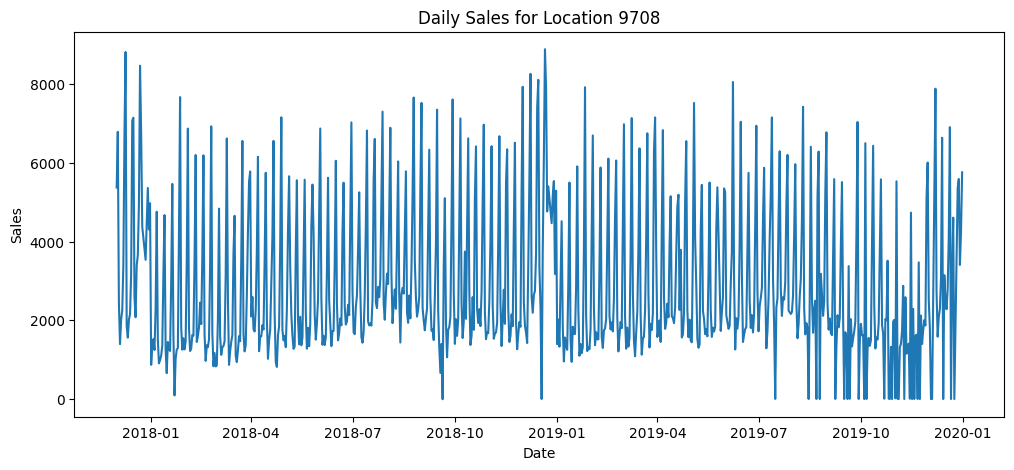

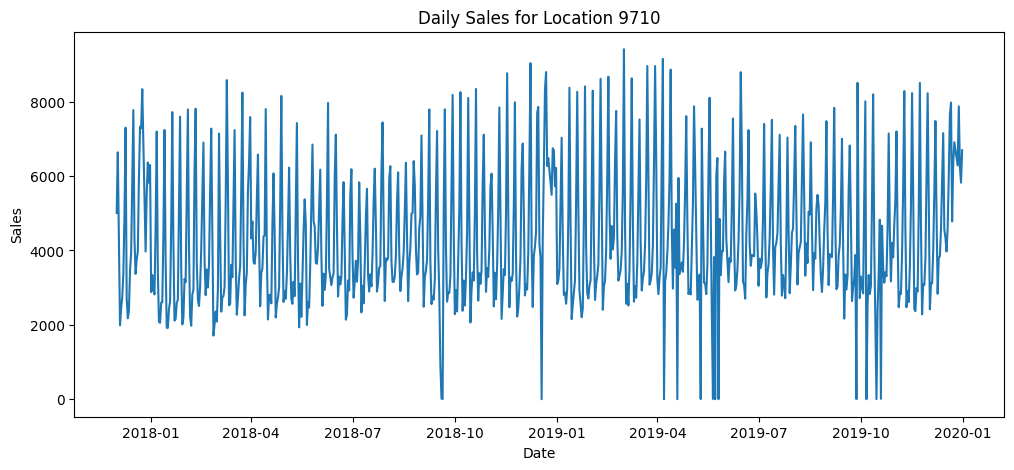

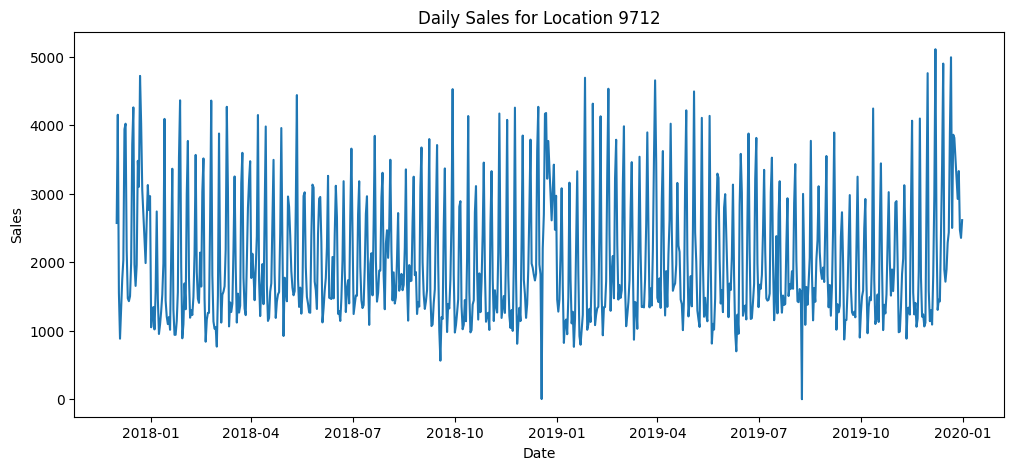

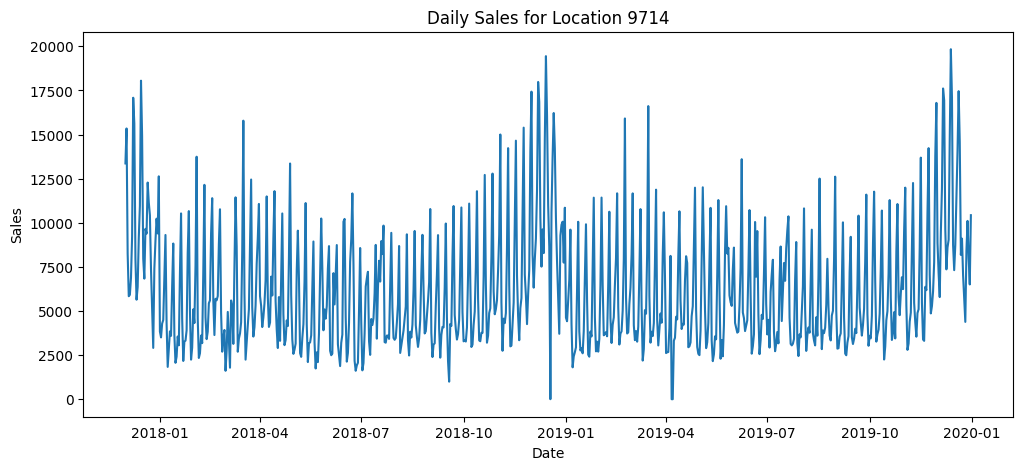

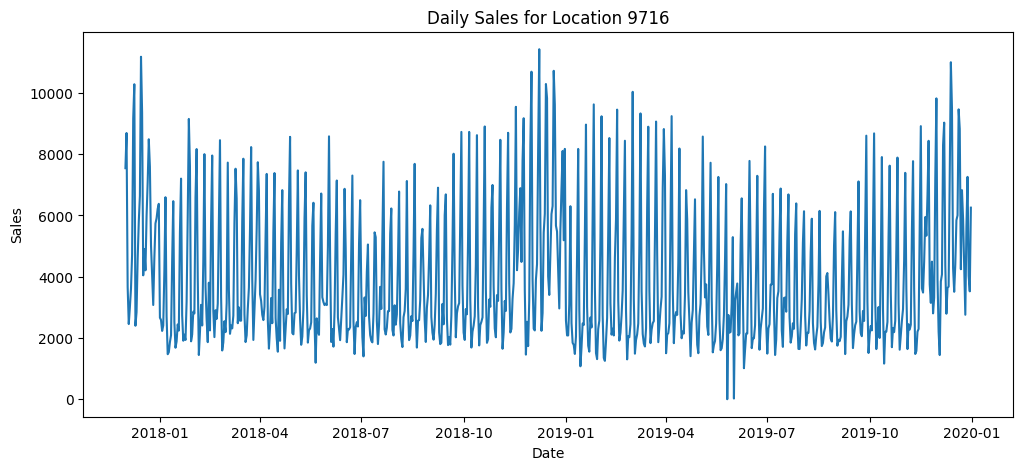

In [ ]:
#Look at the time series plots to check for stationarity and to see if I need to log-transform the data
import matplotlib.pyplot as plt

for int in sorted(df["location"].unique())[:5]:
  df_loc = df[df["location"] == int]

  plt.figure(figsize=(12,5))
  plt.plot(df_loc["date"], df_loc["sales"])
  plt.title(f"Daily Sales for Location {int}")
  plt.xlabel("Date")
  plt.ylabel("Sales")
  plt.show()

In [ ]:
#Show all the locations that have gaps in their dates with their gap counts
gap_counts = (
    df.groupby("location")["date"]
      .apply(lambda s: (s.diff().dt.days > 1).sum())
      .reset_index(name="gap_count")
      .sort_values("gap_count", ascending=False)
)


print(gap_counts.head(1000))

     location  gap_count
61       9797         15
39       9775         14
56       9792         14
59       9795         14
119      9855         13
..        ...        ...
156     14761          1
158     14775          1
157     14768          1
160     14793          1
161     15505          1

[163 rows x 2 columns]


In [ ]:
def fill_missing_dates_with_interpolation(df):
    """
    Ensures each location has continuous daily data
    Missing dates are filled using linear interpolation
    Returns both the filled dataframe and a summary report
    Summary report shows how many days were filled
    """
    df = df.copy()

    filled_dfs = []
    report_rows = []

    for loc, group in df.groupby('location'):
        group = group.set_index('date')

        # Create full daily date range for that location
        full_range = pd.date_range(start=group.index.min(), end=group.index.max(), freq='D')

        # Reindex to include missing days
        group_filled = (
            group.reindex(full_range)
                 .assign(location=loc)
                 .rename_axis('date')
        )

        # Flag which rows were missing (for the summary report)
        was_missing = group_filled['sales'].isna()

        # Fill missing sales using interpolation
        group_filled['sales'] = (
            group_filled['sales']
            .interpolate(method='linear', limit_direction='both')
        )

        # Build report row
        missing_count = was_missing.sum()
        report_rows.append({
            'location': loc,
            'original_days': len(group),
            'filled_days': len(full_range),
            'missing_filled': missing_count
        })

        # Reset index and drop any extra columns, keeping only location, date, sales
        group_filled = group_filled.reset_index()
        group_filled = group_filled[['location', 'date', 'sales']]

        filled_dfs.append(group_filled)

    # Combine everything
    df_filled = pd.concat(filled_dfs, ignore_index=True)
    report = pd.DataFrame(report_rows).sort_values(by='missing_filled', ascending=False)

    return df_filled, report

df_filled, report = fill_missing_dates_with_interpolation(df)
report

,location,original_days,filled_days,missing_filled
31,9767,213,470,257
20,9756,505,761,256
10,9746,212,381,169
134,13042,224,355,131
108,9844,700,761,61
...,...,...,...,...
157,14768,69,71,2
161,15505,12,14,2
143,13091,170,171,1
158,14775,89,90,1


In [ ]:
df_filled

,location,date,sales
0,9708,2017-12-01,5371.933333
1,9708,2017-12-02,6789.400000
2,9708,2017-12-03,2437.080000
3,9708,2017-12-04,1395.700000
4,9708,2017-12-05,2020.300000
...,...,...,...
98730,15512,2019-12-27,3573.933333
98731,15512,2019-12-28,3800.466667
98732,15512,2019-12-29,3053.733333
98733,15512,2019-12-30,3295.133333


In [ ]:
#Check to see that the filled dataset does not have gaps in the daily data
regular_spacing = df_filled.groupby("location")["date"].apply(lambda s: s.diff().dropna().dt.days.eq(1).all())
print(regular_spacing)
print(f'Number of rows that dont have gaps: {regular_spacing.sum()}')

location
9708     True
9710     True
9712     True
9714     True
9716     True
         ... 
14775    True
14786    True
14793    True
15505    True
15512    True
Name: date, Length: 163, dtype: bool
Number of rows that dont have gaps: 163


#### Feature Engineering

In [ ]:
#Add positional encodings as features to represent cycles and seasonality

import numpy as np

def add_date_positional_encodings(df, date_col="date"):
    df = df.copy()
    df[date_col] = pd.to_datetime(df[date_col])

    # Extract components
    df["day_of_week"] = df[date_col].dt.dayofweek
    df["month"] = df[date_col].dt.month
    df["day_of_year"] = df[date_col].dt.dayofyear
    df["year"] = df[date_col].dt.year

    # Cyclical encodings
    df["day_of_week_sin"] = np.sin(2 * np.pi * df["day_of_week"] / 7)
    df["day_of_week_cos"] = np.cos(2 * np.pi * df["day_of_week"] / 7)

    df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

    df["day_of_year_sin"] = np.sin(2 * np.pi * df["day_of_year"] / 365)
    df["day_of_year_cos"] = np.cos(2 * np.pi * df["day_of_year"] / 365)

    # One-hot encode the year, do not need to drop one of the columns
    # because we will not use linear models
    df = pd.get_dummies(df, columns=["year"], prefix="year")

    # Drop non-cyclical date parts (keep only encoded and one-hot features)
    df = df.drop(columns=["day_of_week", "month", "day_of_year"])

    # Make it so that sales is the right-most column
    df = df[[col for col in df.columns if col != "sales"] + ["sales"]]

    return df

df_encoded = add_date_positional_encodings(df_filled)
df_encoded

,location,date,day_of_week_sin,day_of_week_cos,month_sin,month_cos,day_of_year_sin,day_of_year_cos,year_2017,year_2018,year_2019,sales
0,9708,2017-12-01,-0.433884,-0.900969,-2.449294e-16,1.0,-4.937756e-01,0.869589,True,False,False,5371.933333
1,9708,2017-12-02,-0.974928,-0.222521,-2.449294e-16,1.0,-4.787338e-01,0.877960,True,False,False,6789.400000
2,9708,2017-12-03,-0.781831,0.623490,-2.449294e-16,1.0,-4.635503e-01,0.886071,True,False,False,2437.080000
3,9708,2017-12-04,0.000000,1.000000,-2.449294e-16,1.0,-4.482293e-01,0.893919,True,False,False,1395.700000
4,9708,2017-12-05,0.781831,0.623490,-2.449294e-16,1.0,-4.327756e-01,0.901502,True,False,False,2020.300000
...,...,...,...,...,...,...,...,...,...,...,...,...
98730,15512,2019-12-27,-0.433884,-0.900969,-2.449294e-16,1.0,-6.880243e-02,0.997630,False,False,True,3573.933333
98731,15512,2019-12-28,-0.974928,-0.222521,-2.449294e-16,1.0,-5.161967e-02,0.998667,False,False,True,3800.466667
98732,15512,2019-12-29,-0.781831,0.623490,-2.449294e-16,1.0,-3.442161e-02,0.999407,False,False,True,3053.733333
98733,15512,2019-12-30,0.000000,1.000000,-2.449294e-16,1.0,-1.721336e-02,0.999852,False,False,True,3295.133333


In [ ]:
# Show the shortest time series for sliding window approach
location_stats = df.groupby('location').agg(
    days=('date', 'count'),
    start_date=('date', 'min'),
    end_date=('date', 'max')
).sort_values('days')

print(location_stats.head(30))  # 30 shortest time series

          days start_date   end_date
location                            
15505       12 2019-12-18 2019-12-31
15512       20 2019-12-09 2019-12-31
14793       54 2019-11-06 2019-12-31
14786       62 2019-10-28 2019-12-31
14768       69 2019-10-22 2019-12-31
14761       76 2019-10-16 2019-12-31
14775       89 2019-10-03 2019-12-31
14603      111 2019-09-09 2019-12-31
13203      118 2019-09-02 2019-12-31
13106      140 2019-08-12 2019-12-31
13103      154 2019-07-29 2019-12-31
13100      158 2019-07-25 2019-12-31
13097      159 2019-07-14 2019-12-31
13091      170 2019-07-14 2019-12-31
13094      193 2019-06-19 2019-12-31
13083      195 2019-06-09 2019-12-31
13146      208 2019-06-04 2019-12-31
13137      209 2019-06-04 2019-12-31
13168      209 2019-06-02 2019-12-31
13143      209 2019-06-04 2019-12-31
9746       212 2018-12-16 2019-12-31
9767       213 2018-09-18 2019-12-31
13140      213 2019-05-30 2019-12-31
13075      219 2019-05-24 2019-12-31
13036      219 2019-05-24 2019-12-31
1

In [ ]:
# Add sliding window so the model understands Its relation to past values
# Ignore time series with less than 60 datapoints
def add_sliding_window_features(df, window_size=14, min_data_points=60):
    """
    Add sliding window features - only for locations with sufficient data
    """
    df_sliding = df.copy()

    # Count data points per location
    location_counts = df_sliding.groupby('location').size()

    # Only retrieve locations with sufficient data
    valid_locations = location_counts[location_counts >= min_data_points].index

    for location in valid_locations:
        loc_mask = df_sliding['location'] == location

        for i in range(window_size):
            lag = i + 1
            # Make the lag columns using previous values
            df_sliding.loc[loc_mask, f'sales_lag_{lag}'] = (
                df_sliding.loc[loc_mask, 'sales'].shift(lag)
            )

    # For locations with insufficient data, don't add lag features
    # They'll be filtered out later during model training

    return df_sliding

df_sliding = add_sliding_window_features(df_encoded, window_size=14)
df_sliding

,location,date,day_of_week_sin,day_of_week_cos,month_sin,month_cos,day_of_year_sin,day_of_year_cos,year_2017,year_2018,...,sales_lag_5,sales_lag_6,sales_lag_7,sales_lag_8,sales_lag_9,sales_lag_10,sales_lag_11,sales_lag_12,sales_lag_13,sales_lag_14
0,9708,2017-12-01,-0.433884,-0.900969,-2.449294e-16,1.0,-4.937756e-01,0.869589,True,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,9708,2017-12-02,-0.974928,-0.222521,-2.449294e-16,1.0,-4.787338e-01,0.877960,True,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,9708,2017-12-03,-0.781831,0.623490,-2.449294e-16,1.0,-4.635503e-01,0.886071,True,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,9708,2017-12-04,0.000000,1.000000,-2.449294e-16,1.0,-4.482293e-01,0.893919,True,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,9708,2017-12-05,0.781831,0.623490,-2.449294e-16,1.0,-4.327756e-01,0.901502,True,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
98730,15512,2019-12-27,-0.433884,-0.900969,-2.449294e-16,1.0,-6.880243e-02,0.997630,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
98731,15512,2019-12-28,-0.974928,-0.222521,-2.449294e-16,1.0,-5.161967e-02,0.998667,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
98732,15512,2019-12-29,-0.781831,0.623490,-2.449294e-16,1.0,-3.442161e-02,0.999407,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
98733,15512,2019-12-30,0.000000,1.000000,-2.449294e-16,1.0,-1.721336e-02,0.999852,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
#Remove rows with NaNs

df_clean = df_sliding.dropna()
df_clean

,location,date,day_of_week_sin,day_of_week_cos,month_sin,month_cos,day_of_year_sin,day_of_year_cos,year_2017,year_2018,...,sales_lag_5,sales_lag_6,sales_lag_7,sales_lag_8,sales_lag_9,sales_lag_10,sales_lag_11,sales_lag_12,sales_lag_13,sales_lag_14
14,9708,2017-12-15,-0.433884,-0.900969,-2.449294e-16,1.0,-2.719582e-01,0.962309,True,False,...,1850.766667,8816.600000,6707.233333,3401.200000,2246.533333,2020.300000,1395.700000,2437.080000,6789.400000,5371.933333
15,9708,2017-12-16,-0.974928,-0.222521,-2.449294e-16,1.0,-2.553533e-01,0.966848,True,False,...,1559.980000,1850.766667,8816.600000,6707.233333,3401.200000,2246.533333,2020.300000,1395.700000,2437.080000,6789.400000
16,9708,2017-12-17,-0.781831,0.623490,-2.449294e-16,1.0,-2.386728e-01,0.971100,True,False,...,2012.780000,1559.980000,1850.766667,8816.600000,6707.233333,3401.200000,2246.533333,2020.300000,1395.700000,2437.080000
17,9708,2017-12-18,0.000000,1.000000,-2.449294e-16,1.0,-2.219215e-01,0.975065,True,False,...,2155.913333,2012.780000,1559.980000,1850.766667,8816.600000,6707.233333,3401.200000,2246.533333,2020.300000,1395.700000
18,9708,2017-12-19,0.781831,0.623490,-2.449294e-16,1.0,-2.051045e-01,0.978740,True,False,...,3171.166667,2155.913333,2012.780000,1559.980000,1850.766667,8816.600000,6707.233333,3401.200000,2246.533333,2020.300000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
98637,14786,2019-12-27,-0.433884,-0.900969,-2.449294e-16,1.0,-6.880243e-02,0.997630,False,False,...,2717.240000,4864.166667,3937.013333,2715.626667,2079.100000,2527.433333,2027.826667,2430.926667,4135.960000,4195.746667
98638,14786,2019-12-28,-0.974928,-0.222521,-2.449294e-16,1.0,-5.161967e-02,0.998667,False,False,...,2922.333333,2717.240000,4864.166667,3937.013333,2715.626667,2079.100000,2527.433333,2027.826667,2430.926667,4135.960000
98639,14786,2019-12-29,-0.781831,0.623490,-2.449294e-16,1.0,-3.442161e-02,0.999407,False,False,...,3496.766667,2922.333333,2717.240000,4864.166667,3937.013333,2715.626667,2079.100000,2527.433333,2027.826667,2430.926667
98640,14786,2019-12-30,0.000000,1.000000,-2.449294e-16,1.0,-1.721336e-02,0.999852,False,False,...,3473.144444,3496.766667,2922.333333,2717.240000,4864.166667,3937.013333,2715.626667,2079.100000,2527.433333,2027.826667


## Baseline Model



#### Last Value prediction

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
def last_value_baseline(df, target_col='sales', location_col='location', date_col='date'):
    """
    Simple Last Value (Naive) baseline model
    Calculates MAE, RMSE, SMAPE for each location
    """
    # Sort by location and date to ensure proper time order
    df = df.copy()

    results = {}

    for location in df[location_col].unique():
        location_data = df[df[location_col] == location].copy()

        y_true = location_data[target_col].values
        y_pred = location_data['sales_lag_1'].values  # Yesterday's sales

        # Calculate metrics
        mae = mean_absolute_error(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        smape = np.mean(
            2 * np.abs(y_true - y_pred) /
            (np.abs(y_pred) + np.abs(y_true) + 1e-8)) * 100

        # Store results
        results[location] = {
            'mae': mae,
            'rmse': rmse,
            'smape': smape
        }

    return results

# Run the baseline
baseline_results = last_value_baseline(df_clean)
baseline_results

{np.int64(9708): {'mae': 1567.932199910754,
  'rmse': np.float64(2146.341737596957),
  'smape': np.float64(55.35214922238423)},
 np.int64(9710): {'mae': 1506.4556180276663,
  'rmse': np.float64(1978.5688121655946),
  'smape': np.float64(35.519496041626276)},
 np.int64(9712): {'mae': 765.9373136992413,
  'rmse': np.float64(1008.7487082428482),
  'smape': np.float64(35.617088840438115)},
 np.int64(9714): {'mae': 2484.8951182507803,
  'rmse': np.float64(3277.1300318946937),
  'smape': np.float64(38.67941991896483)},
 np.int64(9716): {'mae': 1772.550986166889,
  'rmse': np.float64(2359.9447049694486),
  'smape': np.float64(42.1374929465744)},
 np.int64(9718): {'mae': 1253.1801874163318,
  'rmse': np.float64(1627.917113016611),
  'smape': np.float64(43.934314589742925)},
 np.int64(9720): {'mae': 1132.784016064257,
  'rmse': np.float64(1513.530451763855),
  'smape': np.float64(41.228021364146315)},
 np.int64(9722): {'mae': 989.0537260151715,
  'rmse': np.float64(1273.944158456378),
  'smape'

In [ ]:
def summarize_last_value_baseline(baseline_results):
    """
    Summarize Last Value baseline performance across all locations
    """

    metrics = ['mae', 'rmse', 'smape']
    summary = {}

    for metric in metrics:
        values = [result[metric] for result in baseline_results.values()]
        summary[metric] = {
            'mean': np.mean(values),
            'min': np.min(values),
            'max': np.max(values),
            'median': np.median(values)
        }

    summary_df = pd.DataFrame(summary)

    print("Last Value Baseline - Performance Summary:")
    print(f"Number of locations: {len(baseline_results)}")
    print(f"Average MAE: {summary_df.loc['mean', 'mae']:.2f}")
    print(f"Average RMSE: {summary_df.loc['mean', 'rmse']:.2f}")
    print(f"Average SMAPE: {summary_df.loc['mean', 'smape']:.2f}%")

    return summary_df

# Get summary
summary = summarize_last_value_baseline(baseline_results)


Last Value Baseline - Performance Summary:
Number of locations: 160
Average MAE: 979.13
Average RMSE: 1313.63
Average SMAPE: 36.29%


In [ ]:
summary

,mae,rmse,smape
mean,979.125617,1313.627178,36.289962
min,313.017367,403.872325,9.830983
max,3292.031236,4850.481541,59.770217
median,780.441504,1046.016832,35.568292


In [ ]:
def historical_average_baseline(df, target_col='sales', location_col='location',
                               date_col='date', test_date='2019-12-01'):
    """
    Historical Average baseline model
    Predicts the average of ALL historical sales for each location
    Uses all data before the predicted day, evaluates on December 2019
    Returns MAE, RMSE, SMAPE for each location
    Also returns a dataframe with all predictions and actual values
    """
    df = df.copy()

    results = {}
    all_predictions = []

    for location in df[location_col].unique():
        location_data = df[df[location_col] == location].copy()

        # Get test period (December 2019)
        test_data = location_data[location_data[date_col] >= test_date].copy()

        location_predictions = []
        location_actuals = []

        for test_day in test_data[date_col].unique():
            # Use ALL data available BEFORE this test day
            available_data = location_data[location_data[date_col] < test_day].copy()

            # Calculate average of ALL historical data before test day
            historical_avg = available_data[target_col].mean()

            # Get actual value for this test day
            actual_value = test_data[test_data[date_col] == test_day][target_col].iloc[0]

            location_predictions.append(historical_avg)
            location_actuals.append(actual_value)

            # Store for analysis
            all_predictions.append({
                'location': location,
                'date': test_day,
                'predicted': historical_avg,
                'actual': actual_value,
            })

        # Calculate metrics for this location
        if len(location_predictions) > 0:
            mae = mean_absolute_error(location_actuals, location_predictions)
            rmse = np.sqrt(mean_squared_error(location_actuals, location_predictions))
            smape = np.mean(2 * np.abs(np.array(location_predictions) - np.array(location_actuals)) /
                            (np.abs(location_actuals) + np.abs(location_predictions)+ 1e-8)) * 100

            results[location] = {
                'mae': mae,
                'rmse': rmse,
                'smape': smape,
                'historical_avg_used': historical_avg
            }

    predictions_df = pd.DataFrame(all_predictions)
    return results, predictions_df



In [ ]:
# Run the historical average baseline
historical_baseline_results, historical_predictions = historical_average_baseline(
    df_clean, test_date='2019-12-01'
)
historical_predictions

,location,date,predicted,actual
0,9708,2019-12-01,2859.267048,2512.326667
1,9708,2019-12-02,2858.783171,1797.913333
2,9708,2019-12-03,2857.305636,0.000000
3,9708,2019-12-04,2853.331637,0.000000
4,9708,2019-12-05,2849.368676,2724.233333
...,...,...,...,...
4955,14786,2019-12-27,2723.885362,3425.900000
4956,14786,2019-12-28,2738.821844,4222.160000
4957,14786,2019-12-29,2769.724722,3189.713333
4958,14786,2019-12-30,2778.295918,3217.046667


In [ ]:
# Summarize results
def summarize_historical_baseline(baseline_results):
    """Summarize Historical Average baseline performance"""

    metrics = ['mae', 'rmse', 'smape']
    summary = {}

    for metric in metrics:
        values = [result[metric] for result in baseline_results.values() if not np.isnan(result[metric])]
        if len(values) > 0:
            summary[metric] = {
                'mean': np.mean(values),
                'min': np.min(values),
                'max': np.max(values),
                'median': np.median(values)
            }

    summary_df = pd.DataFrame(summary)

    print(f"Average MAE: {summary_df.loc['mean', 'mae']:.2f}")
    print(f"Average RMSE: {summary_df.loc['mean', 'rmse']:.2f}")
    print(f"Average SMAPE: {summary_df.loc['mean', 'smape']:.2f}%")

    return summary_df

# Get summary
historical_summary = summarize_historical_baseline(historical_baseline_results)
historical_summary

Average MAE: 1310.81
Average RMSE: 1697.50
Average SMAPE: 39.72%


,mae,rmse,smape
mean,1310.811654,1697.501370,39.722520
min,374.700669,447.828878,20.651276
max,4653.970066,6796.904422,97.283697
median,1075.584548,1343.311648,38.206499


## Machine Learning Model


In [ ]:
split_date = '2019-12-01'
train_df = df_clean[df_clean['date'] < split_date].copy()
validation_df = df_clean[df_clean['date'] >= split_date].copy()

In [ ]:
import xgboost as xgb
#Create and train xgboost models for each location

location_models = {}
unique_locations = train_df['location'].unique()

features = [col for col in train_df.columns if col not in ['location', 'date', 'sales']]
target = 'sales'

for location in unique_locations:
    location_train_df = train_df[train_df['location'] == location].copy()

    X_train = location_train_df[features]
    y_train = location_train_df[target]

    # Initialize and train XGBoost model
    model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, random_state=42)
    model.fit(X_train, y_train)

    # Store the trained model
    location_models[location] = model

print(f"Trained models for {len(location_models)} locations.")

Trained models for 160 locations.


In [ ]:
def evaluate_model_performance(predictions_df, location_col, actual_col, predicted_col):
    """
    Calculates evaluation metrics (MAE, RMSE, SMAPE) for each location.
    """
    results = {}
    for location in predictions_df[location_col].unique():
        location_data = predictions_df[predictions_df[location_col] == location].copy()

        y_true = location_data[actual_col].values
        y_pred = location_data[predicted_col].values

        mae = mean_absolute_error(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        smape = np.mean(
            2 * np.abs(y_true - y_pred) /
            (np.abs(y_pred) + np.abs(y_true) + 1e-8)) * 100

        results[location] = {
            'mae': mae,
            'rmse': rmse,
            'smape': smape
        }
    return results

In [ ]:
def iterative_forecast_and_evaluate(df_clean, location_models, features, target, start_date='2019-12-01', horizon=7):
    """
    Performs iterative forecasting for each location using trained models
    and evaluates the performance on the validation period.
    Returns a dataframe with all predictions and actual values.
    """
    all_iterative_predictions = []
    all_forecast_data = []

    for location, model in location_models.items():
        # Filter the dataframe to only rows for that location
        location_data = df_clean[df_clean['location'] == location].copy()

        # Find the earliest possible date after start_date
        actual_start_date_for_location = location_data[location_data['date'] >= start_date]['date'].min()

        # Get the data up to the day before the actual start date for initializing the forecast
        initial_data = location_data[location_data['date'] < actual_start_date_for_location].copy()

        if initial_data.empty:
             print(f"Insufficient historical data for location {location} before {actual_start_date_for_location}. Skipping.")


        # Get the features for the actual start date
        current_features_df = location_data[location_data['date'] == actual_start_date_for_location][features].copy()

        if current_features_df.empty:
             print(f"Missing feature data for location {location} on {actual_start_date_for_location}. Skipping.")


        # Start iterative forecasting
        forecast_dates = pd.date_range(start=actual_start_date_for_location, periods=horizon, freq='D')
        forecast_values = []
        actual_values = []

        # Initialize the features for the first forecast day
        # Use the last known values from initial_data for lags
        last_known_data = initial_data.iloc[-1]
        current_features = current_features_df.iloc[0].to_dict()

        # Manually update the lag features
        for i in range(horizon):
            current_features[f'sales_lag_{i+1}'] = initial_data['sales'].iloc[-(i+1)]


        for i in range(horizon):
            forecast_date = forecast_dates[i]

            # Prepare features for the current forecast day
            # Use current_features which will be updated with the prediction in the loop
            X_forecast = pd.DataFrame([current_features], columns=features)

            # Make prediction
            predicted_sales = model.predict(X_forecast)[0]
            forecast_values.append(predicted_sales)

            # Get the actual value for this date from the original df_clean
            actual_row = location_data[location_data['date'] == forecast_date]
            if not actual_row.empty:
                actual_sales = actual_row[target].iloc[0]
                actual_values.append(actual_sales)
            else:
                actual_values.append(np.nan) # Append NaN if actual data is missing

            # Update features for the next forecast day (shift the lags)
            if i < horizon - 1:
                # Shift existing lag features
                for lag in range(horizon - 1, 0, -1):
                    current_features[f'sales_lag_{lag+1}'] = current_features[f'sales_lag_{lag}']
                # Set the first lag to the current prediction
                current_features['sales_lag_1'] = predicted_sales

                # Update date-related features for the next day
                next_date = forecast_dates[i+1]
                current_features['day_of_week_sin'] = np.sin(2 * np.pi * next_date.dayofweek / 7)
                current_features['day_of_week_cos'] = np.cos(2 * np.pi * next_date.dayofweek / 7)
                current_features['month_sin'] = np.sin(2 * np.pi * next_date.month / 12)
                current_features['month_cos'] = np.cos(2 * np.pi * next_date.month / 12)
                current_features['day_of_year_sin'] = np.sin(2 * np.pi * next_date.dayofyear / 365)
                current_features['day_of_year_cos'] = np.cos(2 * np.pi * next_date.dayofyear / 365)

                # Update year one-hot encoding
                for year_col in [col for col in features if 'year_' in col]:
                    current_features[year_col] = (next_date.year == year_col.split('_')[1])

        # Store iterative predictions for evaluation
        all_iterative_predictions.append(pd.DataFrame({
            'location': location,
            'date': forecast_dates,
            'actual': actual_values,
            'predicted': forecast_values
        }))

        # Store forecast data in the desired format
        forecast_row = {'location': location, 'Date of Prediction': actual_start_date_for_location}
        for i in range(horizon):
            forecast_row[f'Forecast day {i+1}'] = forecast_values[i]
        all_forecast_data.append(forecast_row)


    iterative_predictions_df = pd.concat(all_iterative_predictions, ignore_index=True)
    forecast_output_df = pd.DataFrame(all_forecast_data)

    return iterative_predictions_df, forecast_output_df


In [ ]:
# Run iterative forecasting and get predictions
iterative_predictions, forecast_output = iterative_forecast_and_evaluate(
    df_clean,
    location_models,
    features,
    target,
    start_date='2019-12-01',
    horizon=7
)

In [ ]:

# Evaluate the performance of the iterative predictions
iterative_evaluation_results = evaluate_model_performance(
    iterative_predictions,
    location_col='location',
    actual_col='actual',
    predicted_col='predicted'
)

In [ ]:
iterative_evaluation_results

{np.int64(9708): {'mae': 969.6276327659974,
  'rmse': np.float64(1258.1507023566994),
  'smape': np.float64(68.61075855175488)},
 np.int64(9710): {'mae': 581.6685993303586,
  'rmse': np.float64(698.8863278726477),
  'smape': np.float64(14.856083985813823)},
 np.int64(9712): {'mae': 940.9943745349693,
  'rmse': np.float64(1094.8412735544698),
  'smape': np.float64(43.407258021562626)},
 np.int64(9714): {'mae': 2991.321828497027,
  'rmse': np.float64(3969.6094869124504),
  'smape': np.float64(27.16002365114684)},
 np.int64(9716): {'mae': 1052.4914797247027,
  'rmse': np.float64(1395.5675126902122),
  'smape': np.float64(25.839506530489935)},
 np.int64(9718): {'mae': 2122.3502362351182,
  'rmse': np.float64(2459.350149525194),
  'smape': np.float64(59.87047720703552)},
 np.int64(9720): {'mae': 791.5549637276805,
  'rmse': np.float64(1056.7802038910397),
  'smape': np.float64(66.06975417208314)},
 np.int64(9722): {'mae': 484.47133975074496,
  'rmse': np.float64(728.4234623490489),
  'smape

In [ ]:
forecast_output

,location,Date of Prediction,Forecast day 1,Forecast day 2,Forecast day 3,Forecast day 4,Forecast day 5,Forecast day 6,Forecast day 7
0,9708,2019-12-01,2211.146240,1401.851074,1741.236084,1890.724976,3044.973877,5084.797852,5856.833008
1,9710,2019-12-01,4816.459961,3147.296631,3752.814453,4188.607422,3822.718506,6630.026367,7478.366211
2,9712,2019-12-01,1906.150879,2315.957275,2534.465576,2575.330078,2479.734863,3001.394775,3464.479492
3,9714,2019-12-01,8121.179199,6164.235840,4821.546387,6830.783691,10273.626953,9947.519531,10661.322266
4,9716,2019-12-01,4432.608887,2516.152588,4388.844238,4135.469727,3703.935303,6627.575195,7767.031250
...,...,...,...,...,...,...,...,...,...
155,14603,2019-12-01,3302.209229,2125.313965,2154.524658,2301.295410,2679.250977,2877.479004,833.474121
156,14761,2019-12-01,6102.720703,4917.783691,5240.877930,5673.263672,5566.541016,5989.096680,6015.160156
157,14768,2019-12-01,2687.573730,2198.239990,2345.639160,2608.737305,2534.142334,3749.548096,4992.544434
158,14775,2019-12-01,6600.783691,4734.284668,5583.911621,4991.013184,6127.880371,4528.372559,5322.951660


In [ ]:
def summarize_evaluation_results(evaluation_results):
    """
    Summarize evaluation results across all locations.
    """
    if not evaluation_results:
        print("No results to summarize")
        return None

    metrics = list(list(evaluation_results.values())[0].keys()) # Get metric names from the first location
    summary = {}

    for metric in metrics:
        values = [result[metric] for result in evaluation_results.values() if not np.isnan(result[metric])]
        if len(values) > 0:
            summary[metric] = {
                'mean': np.mean(values),
                'min': np.min(values),
                'max': np.max(values),
                'median': np.median(values)
            }

    summary_df = pd.DataFrame(summary)

    print("Iterative Forecasting Performance Summary:")
    print(f"Average MAE: {summary_df.loc['mean', 'mae']:.2f}")
    print(f"Average RMSE: {summary_df.loc['mean', 'rmse']:.2f}")
    print(f"Average SMAPE: {summary_df.loc['mean', 'smape']:.2f}%")


    return summary_df

# Get summary of iterative forecasting results
iterative_summary = summarize_evaluation_results(iterative_evaluation_results)
display(iterative_summary)

Iterative Forecasting Performance Summary:
Average MAE: 786.73
Average RMSE: 1003.04
Average SMAPE: 27.94%


,mae,rmse,smape
mean,786.729865,1003.039990,27.942402
min,130.431166,155.167468,5.562548
max,2991.321828,4447.439901,116.631366
median,546.793016,678.407161,23.715042


Focus on smape metric because it is scale-agnostic to the different datasets
and mape tends to blow up to infinity with values close to 0.

In [ ]:
# Train and evaluate Prophet models for each location

from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics

prophet_results = {}
prophet_predictions = []

# Filter for locations with sufficient data for Prophet (at least 2 years or so is recommended, but we'll use the same threshold as XGBoost for consistency)
location_counts = df_clean.groupby('location').size()
valid_locations = location_counts[location_counts >= 60].index

for location in valid_locations:
    location_data = df_clean[df_clean['location'] == location].copy()

    # Prophet requires specific column names 'ds' for date and 'y' for the target variable
    prophet_df = location_data[['date', 'sales']].rename(columns={'date': 'ds', 'sales': 'y'})

    # Initialize and fit Prophet model
    # Using default seasonality modes, which might be a good starting point
    model = Prophet()
    model.fit(prophet_df)

    # Make future dataframe for 7 days ahead
    future = model.make_future_dataframe(periods=7)

    # Make predictions
    forecast = model.predict(future)

    # Extract predictions for the validation period (December 2019)
    forecast_dec_2019 = forecast[forecast['ds'] >= '2019-12-01'].copy()

    # Merge with actual values for evaluation
    actual_dec_2019 = location_data[location_data['date'] >= '2019-12-01'].copy()
    evaluation_df = pd.merge(
        forecast_dec_2019[['ds', 'yhat']],
        actual_dec_2019[['date', 'sales']],
        left_on='ds',
        right_on='date',
        how='inner'
    ).rename(columns={'yhat': 'predicted', 'sales': 'actual'})

    # Store predictions for overall evaluation
    evaluation_df['location'] = location
    prophet_predictions.append(evaluation_df[['location', 'ds', 'actual', 'predicted']])


    if not evaluation_df.empty:
        # Calculate metrics for this location
        mae = mean_absolute_error(evaluation_df['actual'], evaluation_df['predicted'])
        rmse = np.sqrt(mean_squared_error(evaluation_df['actual'], evaluation_df['predicted']))
        smape = np.mean(
            2 * np.abs(evaluation_df['actual'] - evaluation_df['predicted']) /
            (np.abs(evaluation_df['predicted']) + np.abs(evaluation_df['actual']) + 1e-8)) * 100

        prophet_results[location] = {
            'mae': mae,
            'rmse': rmse,
            'smape': smape
        }
    else:
        print(f"No data for evaluation for location {location} in December 2019.")


# Concatenate all location predictions
prophet_predictions_df = pd.concat(prophet_predictions, ignore_index=True)

print(f"Evaluated Prophet models for {len(prophet_results)} locations.")

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmptc15_pwi/s7bq7pm0.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmptc15_pwi/9ay9e7mv.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=5750', 'data', 'file=/tmp/tmptc15_pwi/s7bq7pm0.json', 'init=/tmp/tmptc15_pwi/9ay9e7mv.json', 'output', 'file=/tmp/tmptc15_pwi/prophet_model1_kbbcg9/prophet_model-20251024202458.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
20:24:58 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
20:24:58 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmptc1

Evaluated Prophet models for 158 locations.


In [ ]:
# Summarize Prophet evaluation results
prophet_summary = summarize_evaluation_results(prophet_results)
display(prophet_summary)

Iterative Forecasting Performance Summary:
Average MAE: 782.14
Average RMSE: 1034.73
Average SMAPE: 24.45%


,mae,rmse,smape
mean,782.135302,1034.733964,24.447686
min,252.895494,311.591170,13.233050
max,3274.477401,4262.905936,94.460571
median,586.913680,818.779081,21.441412


In [ ]:
# Create and train CatBoost models for each location

!pip install catboost
from catboost import CatBoostRegressor

location_models_catboost = {}
unique_locations_train = train_df['location'].unique()

# Re-using features and target defined for XGBoost
features = [col for col in train_df.columns if col not in ['location', 'date', 'sales']]
target = 'sales'

for location in unique_locations_train:
    location_train_df = train_df[train_df['location'] == location].copy()

    X_train = location_train_df[features]
    y_train = location_train_df[target]

    # Initialize and train CatBoost model
    # Using default parameters for now, can be tuned later
    model = CatBoostRegressor(iterations=100, learning_rate=0.1, depth=6, random_state=42, verbose=0)
    model.fit(X_train, y_train)

    # Store the trained model
    location_models_catboost[location] = model

print(f"Trained CatBoost models for {len(location_models_catboost)} locations.")

# Perform iterative forecasting and evaluate using CatBoost models
iterative_predictions_catboost, forecast_output_catboost = iterative_forecast_and_evaluate(
    df_clean,
    location_models_catboost,
    features,
    target,
    start_date='2019-12-01',
    horizon=7
)

# Evaluate the performance of the iterative predictions from CatBoost
iterative_evaluation_results_catboost = evaluate_model_performance(
    iterative_predictions_catboost,
    location_col='location',
    actual_col='actual',
    predicted_col='predicted'
)

# Summarize CatBoost iterative evaluation results
catboost_summary = summarize_evaluation_results(iterative_evaluation_results_catboost)
display(catboost_summary)

Trained CatBoost models for 160 locations.
Iterative Forecasting Performance Summary:
Average MAE: 722.09
Average RMSE: 932.51
Average SMAPE: 24.68%


,mae,rmse,smape
mean,722.085125,932.505942,24.680480
min,123.031524,155.895474,6.044531
max,3854.759351,4934.405319,117.238135
median,492.991739,601.686685,20.979758


In [ ]:
# Create and train LightGBM models for each location

!pip install lightgbm
import lightgbm as lgb

location_models_lgb = {}
unique_locations_train = train_df['location'].unique()

# Re-using features and target defined for XGBoost
# features = [col for col in train_df.columns if col not in ['location', 'date', 'sales']]
# target = 'sales'

for location in unique_locations_train:
    location_train_df = train_df[train_df['location'] == location].copy()

    X_train = location_train_df[features]
    y_train = location_train_df[target]

    # Initialize and train LightGBM model
    # Using default parameters for now, can be tuned later
    model = lgb.LGBMRegressor(random_state=42)
    model.fit(X_train, y_train)

    # Store the trained model
    location_models_lgb[location] = model

print(f"Trained LightGBM models for {len(location_models_lgb)} locations.")

# Perform iterative forecasting and evaluate using LightGBM models
iterative_predictions_lgb, forecast_output_lgb = iterative_forecast_and_evaluate(
    df_clean,
    location_models_lgb,
    features,
    target,
    start_date='2019-12-01',
    horizon=7
)

# Evaluate the performance of the iterative predictions from LightGBM
iterative_evaluation_results_lgb = evaluate_model_performance(
    iterative_predictions_lgb,
    location_col='location',
    actual_col='actual',
    predicted_col='predicted'
)

# Summarize LightGBM iterative evaluation results
lgb_summary = summarize_evaluation_results(iterative_evaluation_results_lgb)
display(lgb_summary)

Streaming output truncated to the last 5000 lines.
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with posit

,mae,rmse,smape
mean,793.143163,981.832616,27.990853
min,110.769313,120.929566,8.356331
max,3769.399665,4358.684616,116.230558
median,569.112183,674.075776,24.272570


In [ ]:
# Create a dataframe with the mean SMAPE for all models

model_performance_summary = pd.DataFrame({
    'Model': ['Last Value Baseline', 'Historical Average Baseline', 'XGBoost', 'CatBoost', 'LightGBM', 'Prophet'],
    'Mean SMAPE': [
        36.289962, # Replace with actual mean SMAPE from Last Value
        39.722520, # Replace with actual mean SMAPE from Historical Average
        27.942402, # Replace with actual mean SMAPE from XGBoost (assuming iterative_evaluation_results_optimized)
        24.680480, # Replace with actual mean SMAPE from CatBoost
        27.990853,  # Replace with actual mean SMAPE from LightGBM
        24.447686 # Replace with actual mean SMAPE from Prophet
    ]
})

display(model_performance_summary.sort_values(by='Mean SMAPE'))

,Model,Mean SMAPE
5,Prophet,24.447686
3,CatBoost,24.680480
2,XGBoost,27.942402
4,LightGBM,27.990853
0,Last Value Baseline,36.289962
1,Historical Average Baseline,39.722520
